# Data Visualization with Python

## About

In this notebook we will be exploring the [coursera dataset](https://www.kaggle.com/datasets/siddharthm1698/coursera-course-dataset) form kaggle. The dataset describes 891 coursera courses categorized into: rating, enrollments, title, organization, course difficulty and certificate type? 

**Important Note:** 

*To access all the visualizations I propose to open the notebook via the following google colab link due to the use of plotly visualizations:*

https://colab.research.google.com/drive/1KM0WdAYhEKvRYzRMncQoSmqdKGfuNGBU?usp=sharing

***We definded a Guiding Question for this Analysis:***

`What makes a course successful?`

**Note:** We will later define more precisely what success really means for us and how the different categories influence this metric.

## Load the dataset and Overview of the Dataset

***First we import the necessary modules, functions and constants needed:***

**Note:** The used functions can be found in `funcs.py` and the constants in `consts.py`.

In [1]:
import pandas as pd
import numpy as np
import chart_studio.plotly as py
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import cufflinks as cf
import plotly.graph_objects as go

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

init_notebook_mode(connected=True)
cf.go_offline()

In [2]:
from funcs import check_treat_na_values
from funcs import detect_numeric_columns
from funcs import detect_categorical_columns
from funcs import check_duplicate_samples
from funcs import check_duplicate_features
from funcs import prepare_data
from funcs import course_certificate_comparison
from funcs import course_difficulty_comparison
from funcs import categorize_course
from funcs import tech_vs_nontech
from consts import ORGANIZATION_COUNTRY_MAPPING
from consts import COUNTRY_TO_ISO
from consts import COUNTRY_TO_CONTINENT
from consts import COURSERA_DATASET_PATH
from consts import COURSERA_DATASET_AFTER_CLEANING

In [3]:
coursera_data = pd.read_csv(COURSERA_DATASET_PATH, index_col=0, sep=",").sort_index()

In [4]:
coursera_data.head()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,IBM Data Science,IBM,PROFESSIONAL CERTIFICATE,4.6,Beginner,480k
1,Introduction to Data Science,IBM,SPECIALIZATION,4.6,Beginner,310k
2,The Science of Well-Being,Yale University,COURSE,4.9,Mixed,2.5m
3,Python for Everybody,University of Michigan,SPECIALIZATION,4.8,Beginner,1.5m
4,Google IT Support,Google,PROFESSIONAL CERTIFICATE,4.8,Beginner,350k


In [4]:
shape_data = coursera_data.shape
print(
    f"Number of rows - samples: {shape_data[0]} \nNumber of columns - features: {shape_data[1]}"
)

Number of rows - samples: 891 
Number of columns - features: 6


***We successfully loaded the dataset as well as sorting by index, as seen in the printed head of the dataset. The data set has 891 rows and 6 columns.***

## Data Cleaning

***We check whether empty rows exist and drop them if so. Additionally we check for duplicate rows - samples and duplicate columns - features.***

**Note:** We therefore use the `check_treat_na_values, check_duplicate_samples, check_duplicate_features` functions out of `funcs.py`.

In [5]:
coursera_data = check_treat_na_values(coursera_data)

Detected no empty rows.


In [6]:
coursera_data = check_duplicate_samples(coursera_data)

No duplicate samples detected!


In [7]:
coursera_data = check_duplicate_features(coursera_data)

No duplicate features detected!


***We continue by now checking each of the following columns on valid values: course_rating, course_difficulty, course_students_enrolled, course_Certificate_type:***

1. `course_rating` by only allowing values in the range `[0,5]`; border-inclusive.
2. `course_difficulty` by only allowing valid difficulty levels
3. `course_students_enrolled` by checking that the values are `>=0`
4. `course_Certificate_type` by only allowing valid certification types

**Note:** `course_title` and `course_organization` cannot be checked that way; we would need a verifying dataset.

In [8]:
course_rating_mask = coursera_data["course_rating"].between(0.0, 5.0, inclusive="both")
coursera_data = coursera_data[course_rating_mask]
print(f"Number of valid ratings: {course_rating_mask.sum()}")

Number of valid ratings: 891


We sum the number of valid values and see that `all 891 rows have valid ratings`.

In [9]:
course_difficulty_overview = coursera_data["course_difficulty"].value_counts()
print(f"Overview of valid difficulties: \n{course_difficulty_overview}")

print(f"\nTotal number of valid difficulties: {int(course_difficulty_overview.sum())}")

Overview of valid difficulties: 
course_difficulty
Beginner        487
Intermediate    198
Mixed           187
Advanced         19
Name: count, dtype: int64

Total number of valid difficulties: 891


We can see a short overview of the valid difficulties: `Beginner, Intermediate, Mixed, Advanced.` 
By summing these values we see that `all values are valid` with a sum of 891, which is the number of rows in our dataset.

In [10]:
multipliers = {"k": 1000, "m": 1000000}

coursera_data["course_students_enrolled"] = coursera_data[
    "course_students_enrolled"
].map(
    lambda x: (
        float(str(x)[:-1]) * multipliers[str(x)[-1]]
        if str(x)[-1] in multipliers and float(str(x)[:-1]) >= 0
        else float(x)
    )
)
coursera_data["course_students_enrolled"].head()

0     480000.0
1     310000.0
2    2500000.0
3    1500000.0
4     350000.0
Name: course_students_enrolled, dtype: float64

We turned the object values into floats depending on the multiplier: `k(1000) or m(1000000)` for consistency and graphical representations later. We also applied the `>=0`. 

In [11]:
course_certificate_overview = coursera_data["course_Certificate_type"].value_counts()
course_certificate_overview

print(f"Overview of valid certificate types: \n{course_certificate_overview}")

print(
    f"\nTotal number of valid certificate types: {int(course_certificate_overview.sum())}"
)

Overview of valid certificate types: 
course_Certificate_type
COURSE                      582
SPECIALIZATION              297
PROFESSIONAL CERTIFICATE     12
Name: count, dtype: int64

Total number of valid certificate types: 891


We can see a short overview of the valid certification types: `Course, Specialization, Professional certificate.` 
By summing these values we see that `all values are valid` with a sum of 891, which is the number of rows in our dataset.

***Now we create Constants for the numeric and categorical features of our dataset:***

**Note:** We therefore use the `detect_numeric_columns, detect_categorical_columns` functions out of `funcs.py`.

In [12]:
NUMERIC_FEATURES = detect_numeric_columns(coursera_data)
CATEGORICAL_FEATURES = detect_categorical_columns(coursera_data)

print(NUMERIC_FEATURES)
print(CATEGORICAL_FEATURES)

['course_rating', 'course_students_enrolled']
['course_title', 'course_organization', 'course_Certificate_type', 'course_difficulty']


### Outlier Overview and Handling

***We now take a look at the outliers in course_students_enrolled and course_rating:***

**Note:** We only need to check for these features, because those are our `numeric` ones.

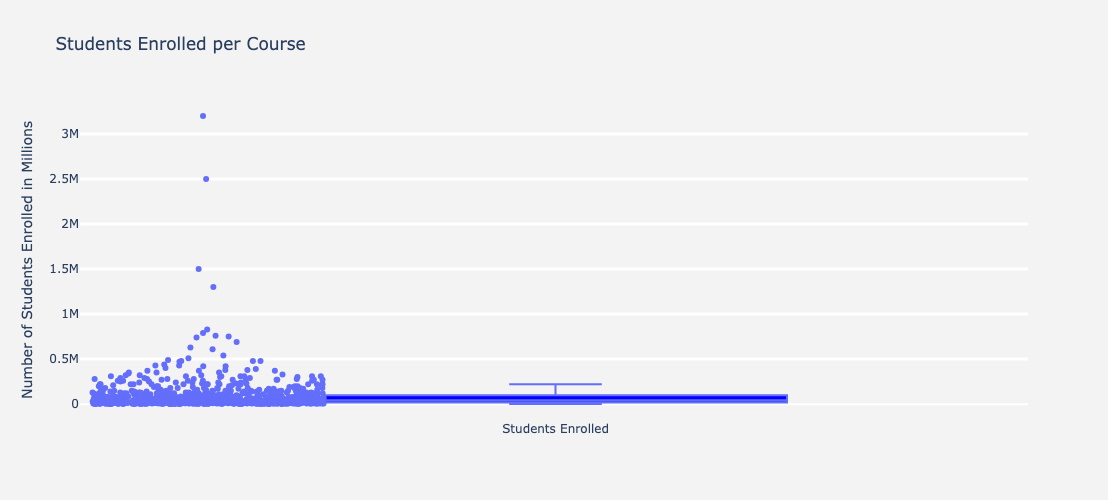

In [13]:
# Create first plot for Students Enrolled
fig_students_plot = go.Figure()
fig_students_plot.add_trace(
    go.Box(
        y=coursera_data["course_students_enrolled"],
        boxpoints="all",
        name="Students Enrolled",
        fillcolor="blue",
        jitter=0.5,
        whiskerwidth=0.2,
    )
)

fig_students_plot.update_layout(
    title="Students Enrolled per Course",
    width=800,
    height=500,
    yaxis=dict(
        title="Number of Students Enrolled in Millions",
        gridcolor="rgb(255, 255, 255)",
        gridwidth=3,
    ),
    paper_bgcolor="rgb(243, 243, 243)",
    plot_bgcolor="rgb(243, 243, 243)",
)

fig_students_plot.show()

As checked before all values are `>=0`. The most values are roughly in a range: `[10k, 100k]`, with a `median: 42k`. There are definitely some outliers at the millions with the `max: 3.2M`, but those are surely `valid values - not anomalies`, which emphasize the range of the student enrollments and therefore should be `kept in the dataset`.

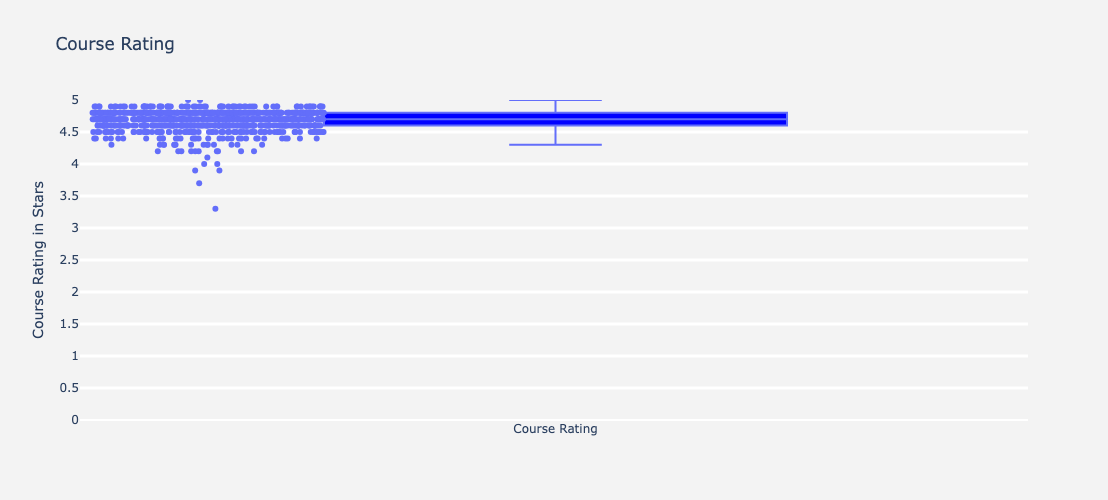

In [14]:
# Create second plot for Course Rating
fig_rating_plot = go.Figure()
fig_rating_plot.add_trace(
    go.Box(
        y=coursera_data["course_rating"],
        boxpoints="all",
        name="Course Rating",
        fillcolor="blue",
        jitter=0.5,
        whiskerwidth=0.2,
    )
)

fig_rating_plot.update_layout(
    title="Course Rating",
    width=800,
    height=500,
    yaxis=dict(
        title="Course Rating in Stars",
        gridcolor="rgb(255, 255, 255)",
        gridwidth=3,
        range=[0, 5],
        dtick=0.5,
    ),
    paper_bgcolor="rgb(243, 243, 243)",
    plot_bgcolor="rgb(243, 243, 243)",
)

fig_rating_plot.show()

All values are in `[0, 5]` as checked before. The most values are roughly in a range: `[4.6, 4.8]`, with a `median: 4.7`. There are definitely some outliers at the millions with the `min: 3.3`, but those are `valid values - not anomalies`, especially cause the ratings are overall pretty good considering the full range. Therefore the outliers should be `kept in the dataset`.

***Export processed dataset to CSV:*** 

In [16]:
coursera_data.to_csv(COURSERA_DATASET_AFTER_CLEANING, index=False)
print(f"Processed dataset saved to {COURSERA_DATASET_AFTER_CLEANING}")

Processed dataset saved to ../Dataset/coursera_data_processed.csv


## Data Analysis

### ***Key Question: What makes a course successful?***

***We define successful: `Success Score = course_rating * log(1+enrollment)`***

**Note:** Why we chose this formula: The logarithmic transformation ensures that both popular and niche courses contribute meaningfully to the overall success score.

In [15]:
success_score = pd.Series(
    coursera_data["course_rating"]
    * np.log1p(coursera_data["course_students_enrolled"]),
    name="success_score",
)

***We will now therefore iteratively raise hypotheses about the factors: topic, organization, course difficulty, certificate type, region/country to get answers:***

***Hypothesis 1: Countries/regions differ in demand - enrollments and quality - ratings. European and North American countries produce more successful courses.***

To properly come to a result we mainly have to consider three metrics and for each of these we create graphics to visualize them:
1. `Number of total courses per country` - Barchart 
2. `Median Enrollment per country` - Geo scatter
3. `Average Rating per country` - Choropleth
4. `Bayesian Success Score per country` - Choropleth

**Note:** We need all of these metrics to differentiate and classify the ratings and enrollments for regions or countries properly - e.g. countries with few courses may receive a high avg rating and cannot be compared just that way to countries who meet the opposite - to come to a conclusion. With the Bayesian shrinkage technique we try to consider all of this.

In [16]:
# Preparing our data by applying the func
coursera_data["success_score"] = success_score

prepared_df = prepare_data(
    df=coursera_data,
    organization_col="course_organization",
    organization_country_mapping=ORGANIZATION_COUNTRY_MAPPING,
    country_to_iso=COUNTRY_TO_ISO,
    country_to_continent=COUNTRY_TO_CONTINENT,
    rating_col="course_rating",
    enroll_col="course_students_enrolled",
    success_col="success_score",
    bayes_strategy="bayesian_shrinkage",
    strong_shrinkage=15.0
)

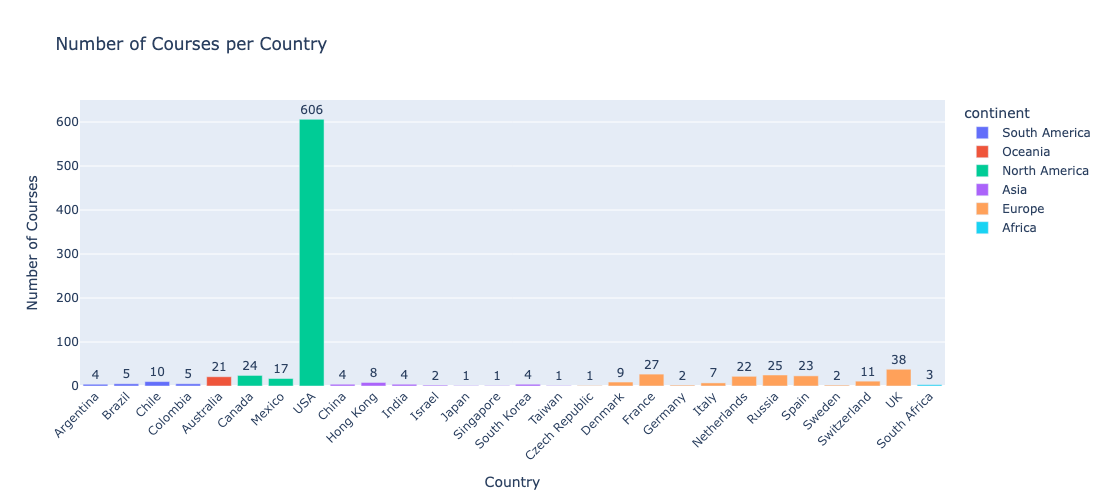

In [17]:
fig = px.bar(
    prepared_df,
    x="country",
    y="course_count",
    color="continent",
    text="course_count",
    title="Number of Courses per Country",
)

fig.update_layout(
    xaxis_title="Country",
    yaxis=dict(title="Number of Courses", range=[0, 650]),
    xaxis_tickangle=-45,
    height=500,
    width=800,
)

fig.update_traces(textposition="outside")
fig.show()

There is `strong dominance of US courses`, followed by Europe as region - mainly represented by the UK(38) - and the other parts of North America. The other regions, including its countries are mainly underrepresented when it comes to the number of courses. 

Number of courses: `US > UK > France > Russia > Canada > ...`

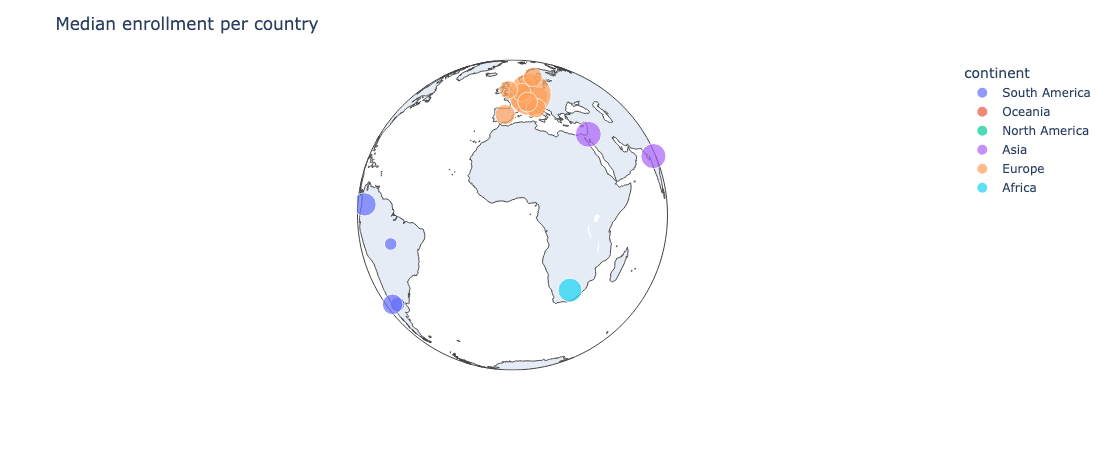

In [18]:
fig = px.scatter_geo(
    prepared_df,
    locations="iso_alpha",
    hover_name="country",
    color="continent",
    size="med_enroll",
    projection="orthographic",
    width=900,
    height=450,
    hover_data={
        "course_count": True,
        "med_enroll": ":.0f",
        "avg_enroll": ":.0f",
        "total_enroll": ":.0f",
        "iso_alpha": False,
    },
    size_max=30,
)
fig.update_layout(title="Median enrollment per country")
fig.show()

Just a quick overview of the broader picture when it comes to enrollment per country. The median enrollment is `mainly on a similar level` with a few outliers; Germany (192.500) and Taiwan (13.000). But this measured value does `not provide much insight`.

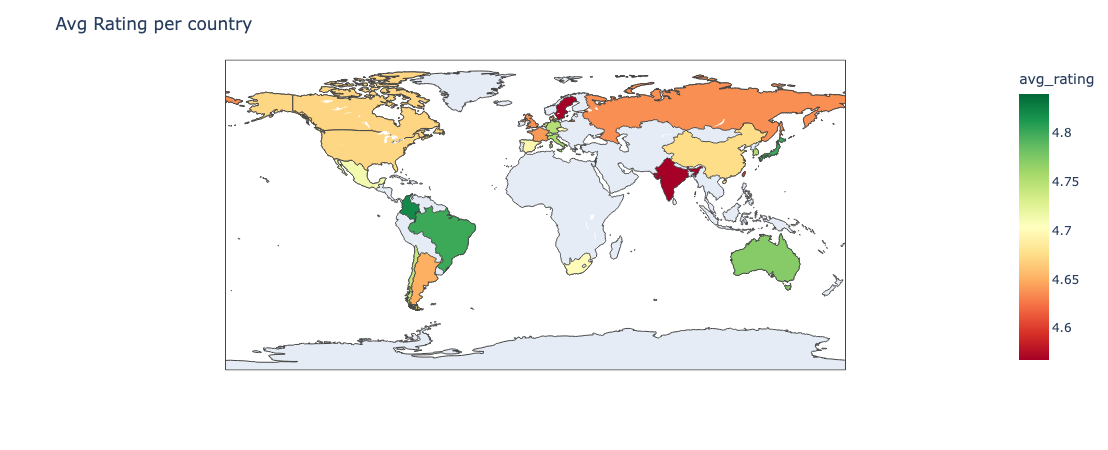

In [19]:
range_lower, range_upper = prepared_df["avg_rating"].quantile([0.05, 0.95])
fig = px.choropleth(
    prepared_df,
    locations="iso_alpha",
    color="avg_rating",
    hover_name="country",
    color_continuous_scale="RdYlGn",
    range_color=(range_lower, range_upper),
    width=900,
    height=450,
)
fig.update_layout(title="Avg Rating per country")
fig.show()

The average rating per country `implies that Colombia, Brazil and Australia produce courses with higher quality - learner satisfaction than the USA, Canada and Europe as a region`. But we are somehow `not considering the total amount of courses` in a country, which may lead to a wrong conclusion. So we will now `finally consider rating, enrollment and total number of courses per country`. 

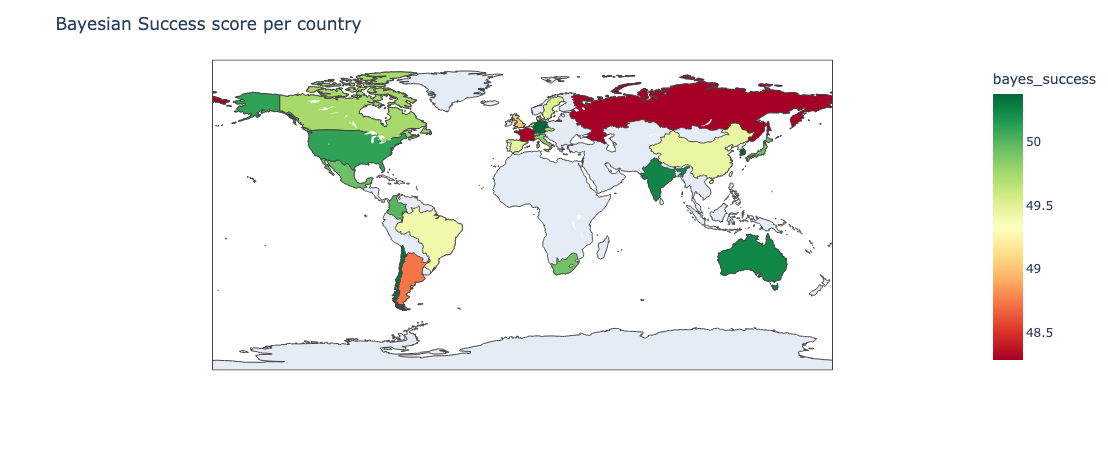

In [20]:
metric = "bayes_success"
q5, q95 = prepared_df[metric].quantile([0.05, 0.95])

fig_bayes_thresh = px.choropleth(
    prepared_df,
    locations="iso_alpha",
    color=metric,
    hover_name="country",
    hover_data=[
        "course_count",
        "avg_rating",
        "avg_enroll",
        "total_enroll",
        "med_success",
    ],
    color_continuous_scale="RdYlGn",
    range_color=(q5, q95),
    scope="world",
    width=900,
    height=450,
)
fig_bayes_thresh.update_layout(
    title="Bayesian Success score per country"
)
fig_bayes_thresh.show()

We are using the `Bayesian shrinkage technique`: country success scores get pulled toward the global average, and that pull gets weaker the more data we have (more enrollments or courses). This helps keep small-sample countries from looking extreme just because of some extreme values and makes the comparison fairer. 
We now see that actually the `USA, Australia, Germany and India (score: 49.8 - 50) are the countries which provide the most successful courses` - based on our definition and calculation. Allthough `Russia (48.8) has the lowest score` here, the `range beween all the countries isnt that huge, as also seen before with the median enrollment and avg. rating`.

**Note:** It may not be the perfect method, but it’s a sensible step up from raw averages, especially cause the dataset does not provide more informations - such as cost, finishing rate, ... .

***Conlusion:***

**-> The hypothesis is partially supported by the data.**

`Regional differences exist but are more nuanced than initially hypothesized. While European and North American countries do demonstrate strong performance in course success metrics, the analysis reveals that successful courses as defined are not exclusively dominated by these regions.`

***However, geographic analysis alone provides an incomplete picture. To fully understand what drives course success and enrollment patterns, we must examine the underlying factors that may explain these differences. Course characteristics such as `difficulty level, certificate type, subject matter and institutional reputation` likely play crucial roles.***

***Hypothesis 2: Professional certificates perform better in terms of ratings, yet courses attract more people (due to free enrollment?).***

To get the full picture we examine:
1. `Distribution of course certificate types` - Pie chart
2. `Relation between certificate type, ratings and enrollment` - 3d scatter
3. `Success Score compared between certificate types` - Boxplot

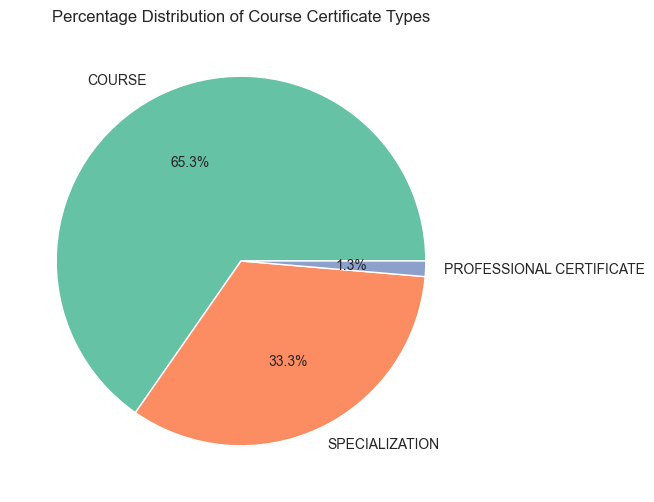

In [30]:
# Certificate distribution pie chart - we use course_certificate_overview
labels = course_certificate_overview.index
counts = course_certificate_overview.values

plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")
plt.pie(
    counts,
    labels=labels,
    autopct="%.1f%%",
    normalize=True,
    colors=sns.color_palette("Set2"),
)

plt.title("Percentage Distribution of Course Certificate Types")

plt.show()

The majority `~2/3 are courses` and `~1/3 are specializations`, and only a tiny minority `~1% are professional certificates`.

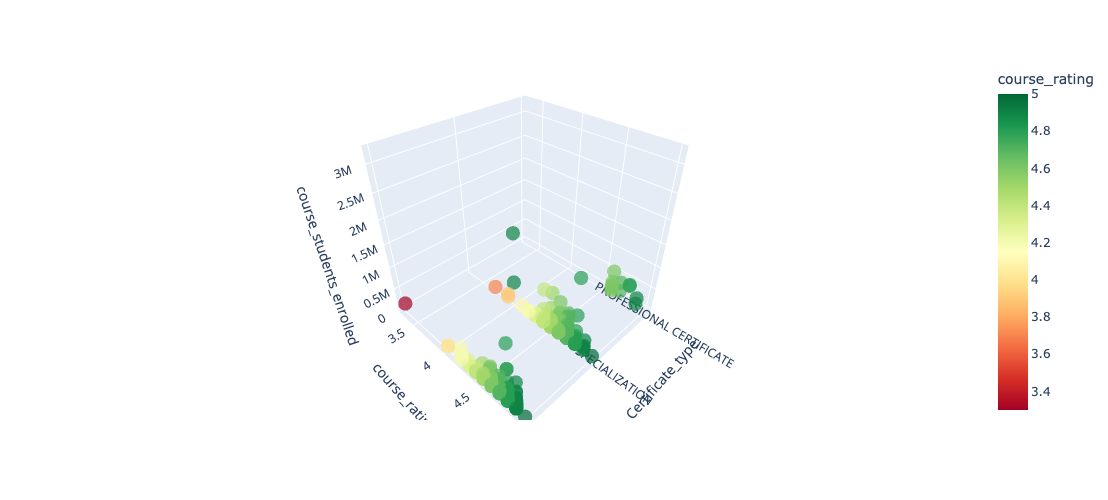

In [ ]:
fig = px.scatter_3d(
    coursera_data,
    x="course_Certificate_type",
    y="course_rating",
    z="course_students_enrolled",
    color="course_rating",
    opacity=0.7,
    width=1000,
    height=500,
    color_continuous_scale="RdYlGn",
)
fig.show()

Enrollment patterns show `clear certificate type preferences`. `Courses attract the highest enrollment volumes`, while `Professional Certificates have the lowest participation rates`; which is probably due to the distribution - dominance of courses and minority of professional certificates. However, `Professional Certificates` demonstrate superior quality consistency with ratings ranging from `4.6 to 5.0 stars`.
Courses exhibit the `widest performance variance` - ratings span from `3.3 to 5.0 stars` with enrollment ranging from `hundreds to over 3.2 million students`. Most courses cluster in the 4.5-5.0 rating range, but notable outliers exist in both directions. `Specializations occupy a middle ground` with moderate enrollment and consistently strong ratings.

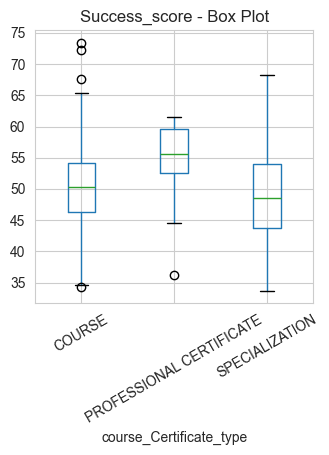

                          count       mean       std        min        25%  \
course_Certificate_type                                                      
COURSE                    582.0  50.192020  5.850270  34.248019  46.305560   
PROFESSIONAL CERTIFICATE   12.0  54.111933  7.596850  36.172796  52.623051   
SPECIALIZATION            297.0  48.718335  6.662868  33.732438  43.830157   

                                50%        75%        max  
course_Certificate_type                                    
COURSE                    50.357868  54.130636  73.395442  
PROFESSIONAL CERTIFICATE  55.546822  59.615041  61.542053  
SPECIALIZATION            48.606341  53.921417  68.260686  


In [24]:
rating_comparison_certificate = course_certificate_comparison(
    coursera_data, "success_score"
)
print(rating_comparison_certificate)

`Professional Certificates lead in success scores (mean: 54.1) followed by Courses (50.2) and Specializations (48.7)`.
 `Courses have the widest range (34.2-73.4)` with highest volume (582 courses). `Specializations showcase a moderate performance`(297 offerings) but lowest mean success `(mean: 48.7)`.

***Conclusion:***

**-> The hypothesis is confirmed.**

`Professional certificates achieve superior ratings (4.6-5.0 stars) and highest success scores (54.1) but attract minimal enrollment. Courses attract higher enrollment showcased by their relationship and the general dominance in number of courses provided (582, ~2/3).`

**Note:** Another hypothesis might be: Professional certificates target career advancement seekers willing to pay premium prices, while courses serve broader educational audiences seeking accessible learning - `more pricing data would strengthen this analysis`.

***Hypothesis 3: Beginner courses attract higher demand than higher difficulty levels; the success score differs less across levels.***

To get the full picture we examine:
1. `Distribution of course difficulty` - Pie chart
2. `Relation between course difficulty, ratings and enrollment` - 3d scatter
3. `Success Score compared between course difficulties` - Boxplot

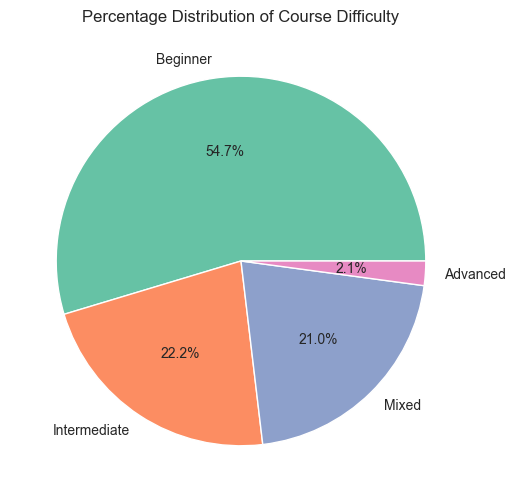

In [29]:
# Course difficulty - pie chart, we use the course_difficulty from the data cleaning part where we made value counts
labels = course_difficulty_overview.index
counts = course_difficulty_overview.values

plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")
plt.pie(counts, labels=labels, autopct="%.1f%%", colors=sns.color_palette("Set2"), normalize=True)

plt.title("Percentage Distribution of Course Difficulty")

plt.show()

`Beginner courses (~55%) dominate`, while `Advanced courses (~2%) are underepresented`. `Intermediate and Mixed` levels are similar, each around `~21–22%`.

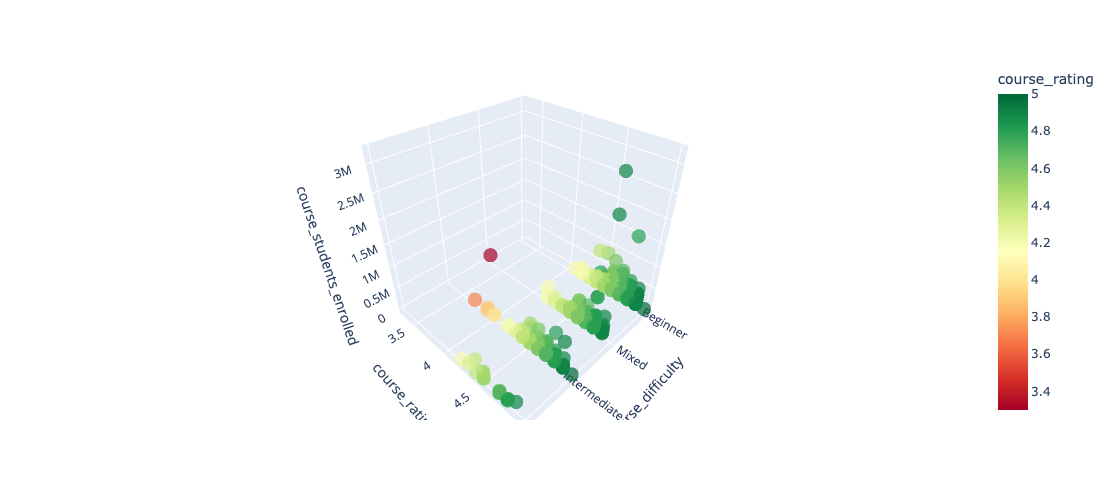

In [26]:
fig = px.scatter_3d(
    coursera_data,
    x="course_difficulty",
    y="course_rating",
    z="course_students_enrolled",
    color="course_rating",
    opacity=0.7,
    width=1000,
    height=500,
    color_continuous_scale="RdYlGn",
)
fig.show()

`Beginner courses dominate`, capturing `high enrollment` numbers while maintaining `strong ratings above 4.0`. Higher-rated courses correlate with increased student enrollment, with Beginner-level content forming the largest cluster of successful courses. However, `Mixed courses contain the absolute highest-enrollment outliers`, with three `courses exceeding one million students (maximum 3.2 million)` - representing the highest enrollment figures overall. `Advanced courses appear less frequently and tend to attract smaller audiences`, while `Mixed - excluding the outliers and Intermediate` courses occupy the `middle ground` in both enrollment and rating distribution.

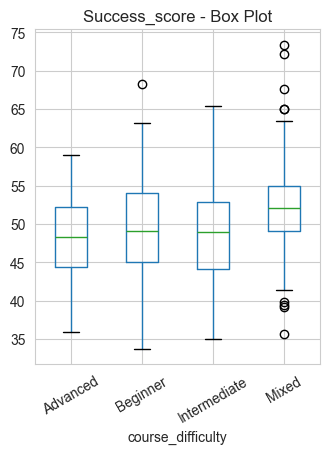

                   count       mean       std        min        25%  \
course_difficulty                                                     
Advanced            19.0  48.141461  6.128691  35.907537  44.323503   
Beginner           487.0  49.360628  6.198301  33.732438  45.033217   
Intermediate       198.0  48.579739  6.289117  34.963166  44.167125   
Mixed              187.0  52.183648  5.524779  35.609056  49.108601   

                         50%        75%        max  
course_difficulty                                   
Advanced           48.292902  52.210746  59.013442  
Beginner           49.040483  54.067299  68.260686  
Intermediate       48.934621  52.867037  65.432036  
Mixed              52.046639  54.967700  73.395442  


In [27]:
rating_comparison_difficulty = course_difficulty_comparison(
    coursera_data, "success_score"
)
print(rating_comparison_difficulty)

`Mixed-level courses have the highest avg success score with around 52, while Advanced, Beginner, and Intermediate courses all perform similarly with averages near 49`. Despite having fewer courses (only 19), `Advanced courses show comparable performance to the larger Beginner (487) and Intermediate (198) categories`. `Mixed courses also exhibit greater variability`, producing both the `greatest max (73)` and more outliers across the performance spectrum.

***Conclusion:***

***-> The hypothesis can be mostly confirmed.***

`Beginner courses represent the majority of offerings (487 courses, 55%) and consistently attract the largest student populations, as evidenced by the dense clustering in the 3D scatter plot. While Mixed courses contain notable enrollment outliers with the highest absolute numbers, they represent exceptions rather than the norm. Success scores remain relatively similar across difficulty levels, though Mixed courses show more variability with outliers trending toward higher performance. Therefore, our hypothesis can be largely confirmed, with the caveat that Mixed-level courses occasionally produce exceptional outliers in both enrollment and success metrics.`

***Hypothesis 4: Organizations with more courses exhibit more enrollments and score higher on our success scale (due to scale/brand effects?).***

Total number of institutions: 154



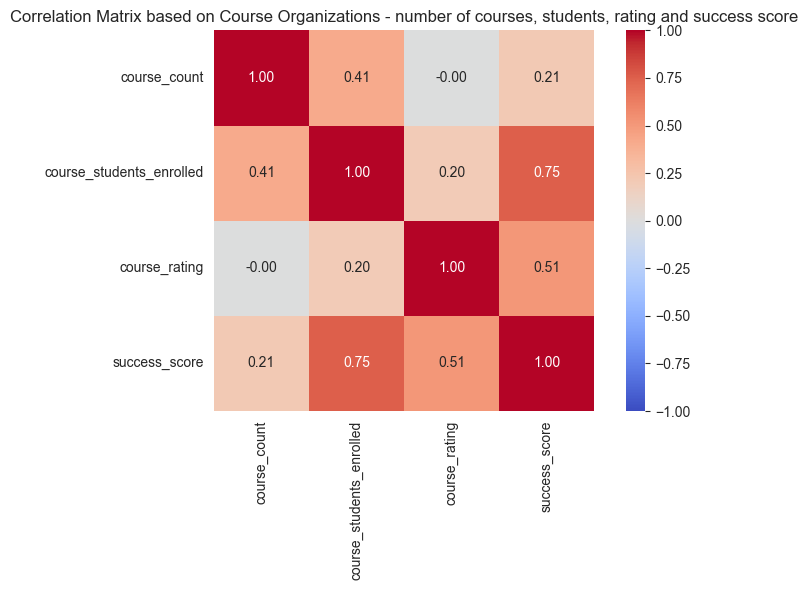

In [ ]:
print(f"Total number of institutions: {coursera_data["course_organization"].nunique()}\n")
# Aggregate avg enrollment, rating, success score and course count per organization
coursera_data_org = coursera_data.groupby('course_organization').agg({
    'course_students_enrolled': 'mean',
    'course_rating': 'mean',            
    'course_organization': 'count',
    'success_score': 'mean'
}).rename(columns={'course_organization': 'course_count'})
correlations = coursera_data_org[["course_count", "course_students_enrolled", 
                          "course_rating", "success_score"]].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0, 
            square=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix based on Course Organizations - number of courses, students, rating and success score")
plt.tight_layout()
plt.show()

We can see that the `enrollment and success_score of organizations are strongly positive correlated with a r = 0.75` (>=0.7). `Course rating and success score` as well as `enrollment and course count` are `slightly positive correlated (r in range 0.41 - 0.51)`. The rest of the correlations are non correlated, with no correlation that is strongly negative correlated.

***Conclusion:***

***-> The hypothesis is partly correct.***

`Organizations with more courses tend to exhibit more enrollments with a correlation score r = 0.41, yet this correlation isnt that strong positive, but it supports the first part of our thesis. The second part of the hypothesis can be refuted by the non correlation of course count and success score (|r| < 0.3).` 

`However organizations with a high avg. enrollment tend to be more successful.`

***Hypothesis 5: Tech related courses dominate the dataset and are more successful.***

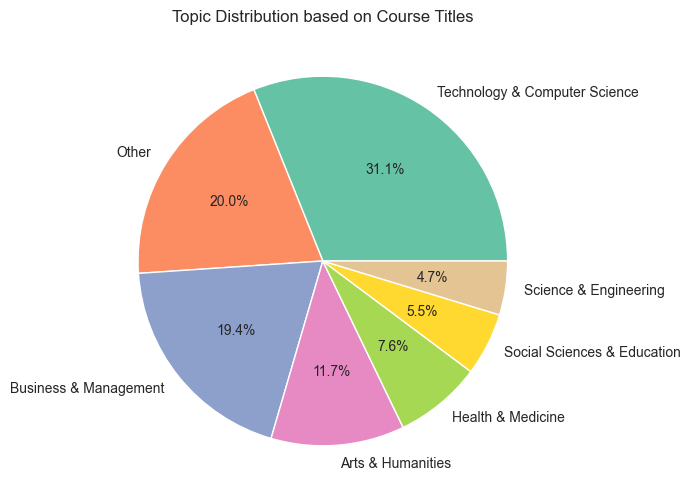

In [31]:
# Distribution of fields of studies, course title - pie chart
category_series = coursera_data["course_title"].apply(categorize_course)
category_count = category_series.value_counts()

labels = category_count.index
counts = category_count.values

plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")
plt.pie(counts, labels=labels, autopct="%.1f%%", colors=sns.color_palette("Set2"), normalize=True)

plt.title("Topic Distribution based on Course Titles")

plt.show()

The `highest single percentage value is Technology & Computer science with ~31%`, followed by Other and Business & Management (~19-20%). 

But if you look at the `broader picture, excluding Other; Non Technical courses dominate`: (Business & Management, Arts & Humanities, Health & Medicine and Social Sciences & Education) `Non technical courses with a total percentage of 44.2%` vs. (Technology & Computer Science and Science and Engineering) -> `Technical courses with a total percentage of 35.8%`.

In [30]:
# Tech (Technology and Computer science, science and engineering) vs. Non tech success score (the rest, excluding other)
coursera_data_copy = coursera_data.copy()
coursera_data_copy["course_category"] = category_series

coursera_data_copy['tech_category'] = coursera_data_copy['course_category'].apply(tech_vs_nontech)

tech_comparison = coursera_data_copy[coursera_data_copy['tech_category'] != 'Other'].groupby('tech_category').agg({
    'success_score': ['mean', 'median', 'std'],
    'course_students_enrolled': 'mean',
    'course_title': 'count' 
}).round(3)

print("Tech vs Non-Tech Success Score Comparison:")
print(tech_comparison)

Tech vs Non-Tech Success Score Comparison:
              success_score                course_students_enrolled  \
                       mean  median    std                     mean   
tech_category                                                         
Non-Tech             49.472  49.602  5.713                70181.726   
Tech                 50.053  50.330  6.897               121605.329   

              course_title  
                     count  
tech_category               
Non-Tech               394  
Tech                   319  


`Non Tech and Tech courses are overall pretty similar when it comes to the avg, median and std success score and the number of courses`. But on `average more students are enrolled in Tech courses than Non Tech courses: ~122.000 > ~70.000`.

**Note:** We exclude the 'Other' category as it may contain technology-related courses that were not captured in our initial filtering process.

***Conclusion:***

***-> The hypothesis was disproven.***

`Only considering the single greatest percentage value would strengthen the first part of the hypothesis, but the broader picture outweighs the single percentage value. The second part is just a false assumption, their average and mean success scores are pretty much the same with nearly the same amount of total courses.`

## Results and Final Conclusion

### What makes a course successful:

- **High quality (rating)**: Central driver; contributes strongly across groups. (H2, H3, H4)
- **Sufficient reach (enrollments)**: Matters, but with limited influence due to log scaling; extreme outliers are not required. (H2, H3, H4)
- **Certificate type**: Professional Certificates achieve the highest success (quality + adequate reach), while standard Courses are leading enrollments. (H2)
- **Course Difficulty**: Beginner- and Mixed-level courses reach the largest audiences; Mixed-level shows the highest average success. (H3)
- **Subject**: Tech attracts more students on average but is not inherently more successful than Non‑Tech. (H5)
- **Organization total number of courses**: Having many courses alone does not raise success; each course must deliver quality and demand. (H4)
- **Country/Region**: Differences exist, but they are small; geography is not a dominant factor. (H1)

### Final overall conclusion
A successful course combines very strong ratings with sufficient—but not necessarily extreme—reach. Ratings lead in impact; enrollment amplifies. Formats like Professional Certificates support high success, whereas Beginner/Mixed levels help drive demand. Neither a Tech label, country, nor organization size guarantees success.

#### How to improve the dataset
Pricing, completion rate would further sharpen the analysis, we could include that in our analysis and also differentiate between the success for businesses wanting to improve their employees skills as well as on an individual level.